# 4. Evaluation Metrics for Classification

### 4.1 Logistic Regression Model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [5]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [6]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [7]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression()
model.fit(X_train, y_train)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

The model has an accuracy of 80% but how do we know if 80% is good or bad? How good or bad it is compared to something?

### 4.2 Accuracy and dummy model

One of the factors affecting the model accuracy is the threshold *t* used in the final prediction of the logistic regression. The model we have currently used a threshold t = 0.5 but the threshold is arbitrary and can be varied to see how the accuracy of the model changes.

In [9]:
from sklearn.metrics import accuracy_score

In [10]:
accuracy_score(y_val, y_pred >= 0.5)

0.8034066713981547

In [11]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('%.2f with accruacy %.3f' % (t, score))
    scores.append(score)

0.00 with accruacy 0.274
0.05 with accruacy 0.509
0.10 with accruacy 0.591
0.15 with accruacy 0.667
0.20 with accruacy 0.710
0.25 with accruacy 0.737
0.30 with accruacy 0.760
0.35 with accruacy 0.772
0.40 with accruacy 0.785
0.45 with accruacy 0.793
0.50 with accruacy 0.803
0.55 with accruacy 0.801
0.60 with accruacy 0.795
0.65 with accruacy 0.786
0.70 with accruacy 0.765
0.75 with accruacy 0.744
0.80 with accruacy 0.735
0.85 with accruacy 0.726
0.90 with accruacy 0.726
0.95 with accruacy 0.726
1.00 with accruacy 0.726


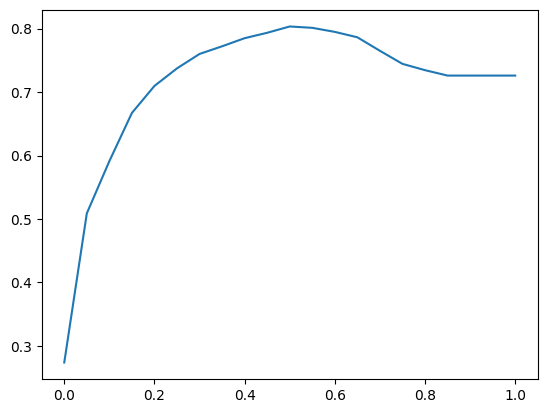

In [12]:
plt.plot(thresholds, scores)

In [14]:
from collections import Counter

In [15]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [16]:
1 - y_val.mean()

np.float64(0.7260468417317246)

72.6% is the base accuracy even if we predict all customers do not churn. It is not too far off from the model we developed. 

### 4.3 Confusion table